**Importations et chargement des données**

In [ ]:
# Cellule 1 — Importations et chargement des données

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set(style="whitegrid")


In [ ]:
# Chargement du dataset IRIS
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# Conversion en DataFrame pour une meilleure lisibilité
df_iris = pd.DataFrame(X, columns=feature_names)

print("Dataset IRIS chargé avec succès.")
df_iris.head()

Dataset IRIS chargé avec succès.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


**Analyse exploratoire rapide (EDA)**

In [ ]:
# Analyse exploratoire rapide

print("Informations générales sur le dataset :")
print(df_iris.info())

print("\nStatistiques descriptives :")
df_iris.describe()


Informations générales sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

Statistiques descriptives :


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


KeyError: 'species'

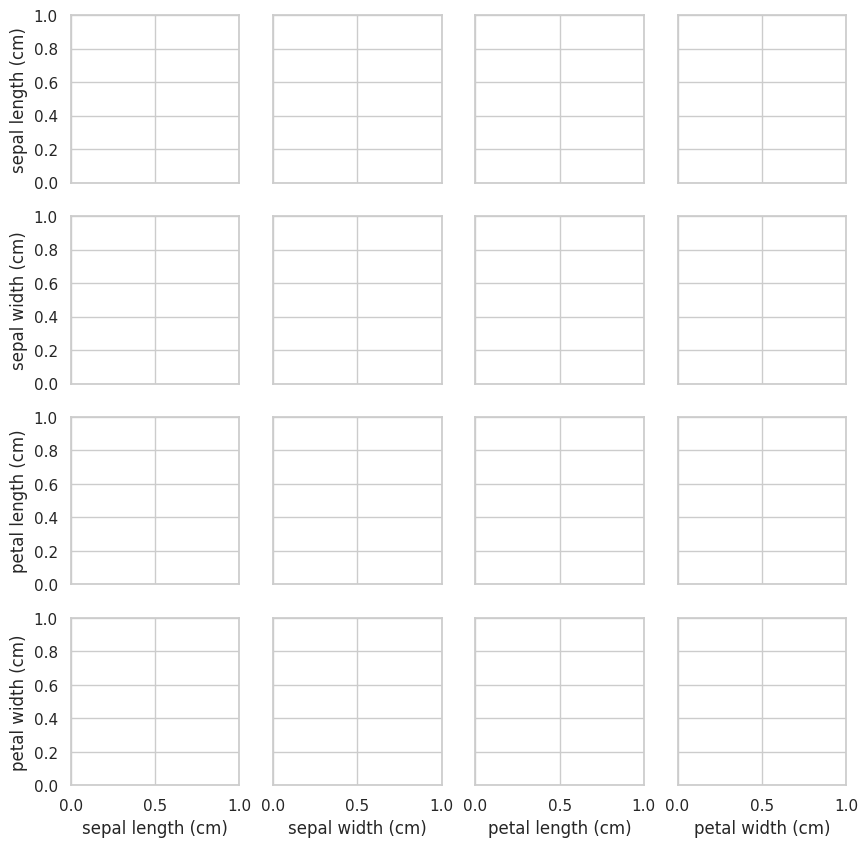

In [ ]:
# Visualisation simple : distribution des longueurs de pétales et sépales

sns.pairplot(df_iris, vars=iris.feature_names, hue="species")
plt.suptitle("Visualisation des variables du dataset Iris", y=1.02)
plt.show()

**Préparation des données pour K-Means**

In [ ]:
# Préparation des données pour K-Means

# On utilise uniquement les variables numériques (4 features)
X = df_iris[iris.feature_names].values

# Standardisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Forme des données avant scaling :", X.shape)
print("Forme des données après scaling  :", X_scaled.shape)


Forme des données avant scaling : (150, 4)
Forme des données après scaling  : (150, 4)


**Choix du nombre de clusters (méthode du coude)**

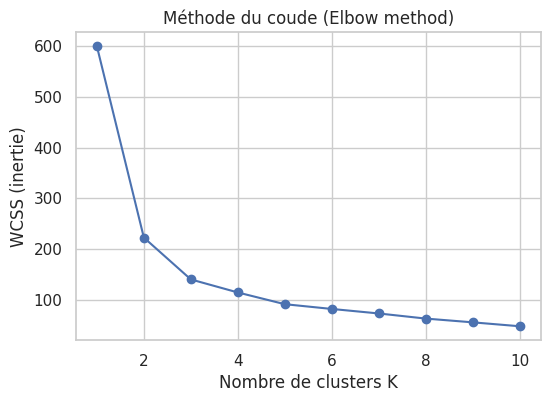

In [ ]:
# Méthode du coude pour choisir K

wcss = []  # Within-Cluster Sum of Squares

K_values = range(1, 11)

for k in K_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_values, wcss, marker='o')
plt.title("Méthode du coude (Elbow method)")
plt.xlabel("Nombre de clusters K")
plt.ylabel("WCSS (inertie)")
plt.grid(True)
plt.show()


**Entraînement du modèle K-Means avec K = 3**

In [ ]:
# Entraînement du modèle K-Means (K = 3)

k = 3
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
kmeans.fit(X_scaled)

# Étiquettes de clusters prédites
cluster_labels = kmeans.labels_

print("Taille de chaque cluster :")
unique, counts = np.unique(cluster_labels, return_counts=True)
for cl, count in zip(unique, counts):
    print(f"Cluster {cl} : {count} points")


Taille de chaque cluster :
Cluster 0 : 53 points
Cluster 1 : 50 points
Cluster 2 : 47 points


**Évaluation du clustering (silhouette score)**

In [ ]:
# Évaluation du clustering avec le score de silhouette

sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"Score de silhouette pour K = {k} : {sil_score:.4f}")


Score de silhouette pour K = 3 : 0.4599


**Visualisation des clusters (2D)**

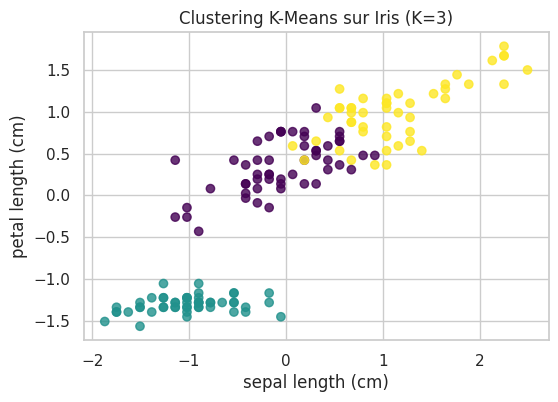

In [ ]:
# Visualisation 2D des clusters

plt.figure(figsize=(6,4))

# On choisit deux features pour la visualisation
x_feature = 0  # sepal length
y_feature = 2  # petal length

plt.scatter(
    X_scaled[:, x_feature],
    X_scaled[:, y_feature],
    c=cluster_labels,
    cmap="viridis",
    alpha=0.8
)

plt.title("Clustering K-Means sur Iris (K=3)")
plt.xlabel(iris.feature_names[x_feature])
plt.ylabel(iris.feature_names[y_feature])
plt.grid(True)
plt.show()


**Résumé**

Type d’algorithme : K-Means (clustering, apprentissage non supervisé)

Dataset : Iris (4 variables numériques, 3 espèces)

Prétraitement : Standardisation des features

Choix de K : Méthode du coude ⇒ K ≈ 3

Évaluation : Score de silhouette + comparaison visuelle

Visualisation : Scatter 2D coloré par cluste